In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df=pd.read_csv('house_dataset.csv', usecols=['GarageQual','FireplaceQu','SalePrice'])
df.sample(5)

,FireplaceQu,GarageQual,SalePrice
76,NaN,TA,135750
787,NaN,TA,233000
1083,Gd,TA,160000
1396,TA,TA,160000
407,NaN,TA,177000


In [20]:
df.isnull().mean() *100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

### Filling by Most Frequent Value (Mode)

In [21]:
df.GarageQual.value_counts()

GarageQual
TA    1311
Fa      48
Gd      14
Ex       3
Po       3
Name: count, dtype: int64

In [22]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: str

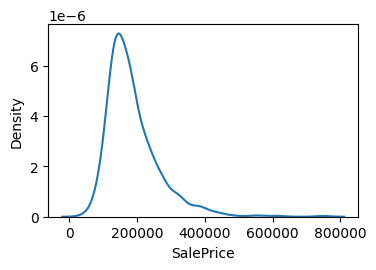

In [36]:
plt.figure(figsize=(4,2.5))
filtered = df[df['GarageQual']=='TA']
sns.kdeplot(filtered.SalePrice)
plt.show()


In [42]:
df['GarageQual'] = df['GarageQual'].fillna('TA')

In [43]:
df.isnull().sum()

FireplaceQu    690
GarageQual       0
SalePrice        0
dtype: int64

In [44]:
df['GarageQual'].value_counts()

GarageQual
TA    1392
Fa      48
Gd      14
Ex       3
Po       3
Name: count, dtype: int64

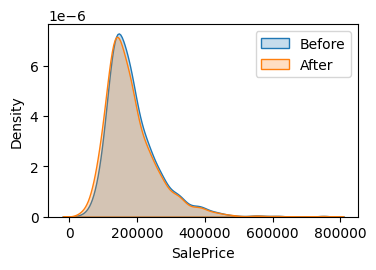

In [50]:
plt.figure(figsize=(4,2.5))
sns.kdeplot(filtered['SalePrice'],fill= True, label='Before') # Null value exists
sns.kdeplot(df['SalePrice'], fill= True, label='After') # After
plt.legend()
plt.show()

In [51]:
#Overlap -> no more values

In [54]:
#FireplaceQu

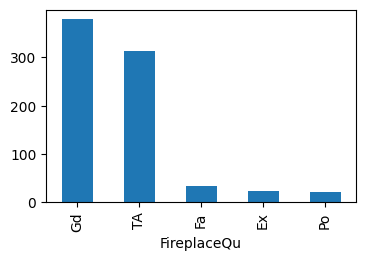

In [59]:
plt.figure(figsize=(4,2.5))
df['FireplaceQu'].value_counts().plot(kind='bar')
plt.show()

In [60]:
# here mode =Gd , moreover, TA is little bit below
# while using this mode way, it is better to dominate by one column totally over other unlike here.

In [61]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: str

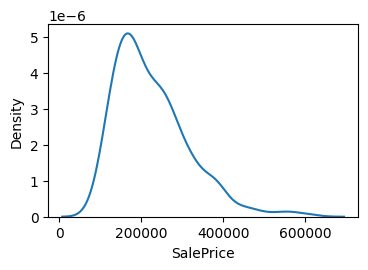

In [64]:
plt.figure(figsize=(4,2.5))
#df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde')
filtered = df[df['FireplaceQu']=='Gd']
sns.kdeplot(filtered.SalePrice)
plt.show()

In [65]:
df['FireplaceQu']= df['FireplaceQu'].fillna('Gd')

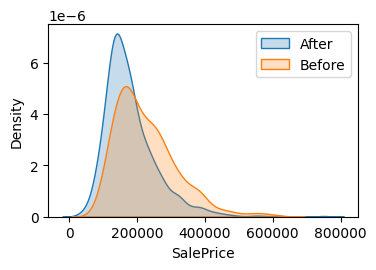

In [69]:
plt.figure(figsize=(4,2.5))
sns.kdeplot(df.SalePrice, fill =True, label='After')
sns.kdeplot(filtered.SalePrice, fill= True, label='Before')
plt.legend()
plt.show()

In [70]:
#don't use in this type of behaviour

#### Doing samething using Scikitlearn 

In [71]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop('SalePrice', axis=1), df['SalePrice'], test_size=0.2, random_state=42)

In [73]:
from sklearn.impute import SimpleImputer

In [74]:
imputer = SimpleImputer(strategy='most_frequent')

In [75]:
X_train = imputer.fit_transform(X_train)
X_test= imputer.transform(X_test)

In [76]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)

### Filling by Missing

In [77]:
df=pd.read_csv('house_dataset.csv', usecols=['GarageQual','FireplaceQu','SalePrice'])

In [78]:
#using Pandas
df['GarageQual'] = df['GarageQual'].fillna('Missing')

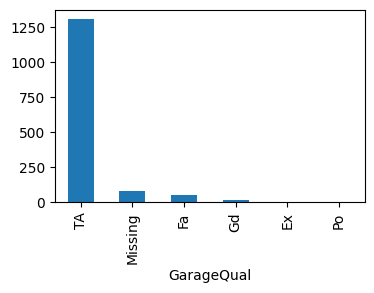

In [80]:
plt.figure(figsize=(4,2.5))
df['GarageQual'].value_counts().plot(kind='bar')
plt.show()

In [81]:
#using sklearn

X_train, X_test, y_train, y_test = train_test_split(df.drop('SalePrice', axis=1),df.SalePrice, random_state=42, test_size=0.2)

In [82]:
imputer = SimpleImputer(strategy='constant', fill_value='Missing')

In [83]:
X_train = imputer.fit_transform(X_train)
X_test= imputer.transform(X_test)
imputer.statistics_

array(['Missing', 'Missing'], dtype=object)